In [1]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from tqdm import tqdm
import pandas as pd
import sys
import joblib
from scipy.special import softmax
from neuro import config
import numpy as np
from collections import defaultdict
from copy import deepcopy
import pandas as pd
import neuro.sasc.viz
import neuro.viz
from neuro.sasc import analyze_helper
import neuro.sasc
from neuro.sasc.modules.fmri_module import convert_module_num_to_voxel_num
from scipy.stats import false_discovery_control
import dvu
dvu.set_style()

# pcs = joblib.load(join(FMRI_DIR, "voxel_neighbors_and_pcs", "loo_pc_UTS02.pkl"))
# pcs['good_voxels'].shape
# pcs['pca_projections'].shape

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/home/chansingh/automated-brain-explanations/.venv/lib/python3.12/site-packages/spacy/cli/_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
/home/chansingh/automated-brain-explanations/.venv/lib/python3.12/site-packages/weasel/util/config.py:8: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string


In [10]:
# pilot_name = 'pilot_story_data.pkl'
pilot_name = 'pilot3_story_data.pkl'
# pilot_name = 'pilot4_story_data.pkl'
# pilot_name = "pilot6_story_data.pkl"
# pilot_name = "pilot8_story_data.pkl"

stories_data_dict = joblib.load(
    join(config.RESULTS_DIR_LOCAL, 'gct_processed', pilot_name))
if pilot_name == 'pilot_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20230504')
elif pilot_name == 'pilot3_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20231106')
elif pilot_name == 'pilot4_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20240509')
elif pilot_name == 'pilot6_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20241202')
elif pilot_name == 'pilot7_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20241204')
elif pilot_name == 'pilot8_story_data.pkl':
    pilot_data_dir = join(config.PILOT_STORY_DATA_DIR, '20241204')

In [11]:
# load responses
default_story_idxs = np.where(
    (np.array(stories_data_dict['story_setting']) == 'default') |
    (np.array(stories_data_dict['story_setting']) == 'roi')
)[0]
resp_np_files = [stories_data_dict['story_name_new'][i].replace('_resps', '')
                 for i in default_story_idxs]
resps_dict = {
    k: np.load(join(pilot_data_dir, k))
    for k in tqdm(resp_np_files)
}

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:07<00:00,  3.70s/it]


In [12]:
mats = defaultdict(list)
resp_chunks = defaultdict(list)
if pilot_name in ['pilot1']:
    use_clusters_list = [False, True]
else:
    use_clusters_list = [False]
for use_clusters in use_clusters_list:
    for story_num in default_story_idxs:
        rows = stories_data_dict["rows"][story_num]

        # get resp_chunks
        resp_story = resps_dict[
            stories_data_dict["story_name_new"][story_num].replace(
                '_resps', '')
        ].T  # (voxels, time)
        timing = stories_data_dict["timing"][story_num]
        if 'paragraphs' in stories_data_dict.keys():
            paragraphs = stories_data_dict["paragraphs"][story_num]
        else:
            paragraphs = stories_data_dict["story_text"][story_num].split(
                "\n\n")
        # paragraphs = stories_data_dict["story_text"][story_num].split("\n\n")
        if pilot_name in ['pilot3_story_data.pkl']:
            paragraphs = [neuro.sasc.analyze_helper.remove_repeated_words(
                p) for p in paragraphs]
        assert len(paragraphs) == len(
            rows), f"{len(paragraphs)} != {len(rows)}"
        resp_chunks = analyze_helper.get_resps_for_paragraphs(
            timing, paragraphs, resp_story, offset=2, validate=True,
            split_hyphens=pilot_name in ["pilot6_story_data.pkl", "pilot7_story_data.pkl", "pilot8_story_data.pkl"])
        assert len(resp_chunks) <= len(paragraphs)

        # calculate mat
        mat = np.zeros((len(rows), len(paragraphs)))
        for i in range(len(resp_chunks)):
            if use_clusters == False:
                # driving single voxel
                if 'voxel_num' in rows.columns:
                    mat[:, i] = resp_chunks[i][rows["voxel_num"].values].mean(
                        axis=1).flatten()
                elif 'voxel_nums' in rows.columns:
                    mat[:, i] = [resp_chunks[i][x].mean()
                                 for x in rows['voxel_nums']]
                    # resp_chunks[i][rows["voxel_nums"].values].mean(
                    # axis=1).flatten()

            elif use_clusters == True:
                for r in range(len(rows)):
                    cluster_nums = rows.iloc[r]["cluster_nums"]
                    if isinstance(cluster_nums, np.ndarray):
                        vals = resp_chunks[i][cluster_nums].flatten()
                        mat[r, i] = np.nanmean(vals)
                    else:
                        # print(cluster_nums)
                        mat[r, i] = np.nan
        mat[:, 0] = np.nan  # ignore the first column
        # print('mat', mat)

        # sort by voxel_num
        if 'voxel_num' in rows.columns:
            args = np.argsort(rows["voxel_num"].values)
        elif pilot_name in ["pilot6_story_data.pkl", "pilot7_story_data.pkl", "pilot8_story_data.pkl"]:
            args = np.argsort(rows["expl"].values)
        else:
            args = np.argsort(rows["roi"].values)
        mat = mat[args, :][:, args]
        mats[use_clusters].append(deepcopy(mat))

        # plt.imshow(mat)
        # plt.colorbar(label="Mean response")
        # plt.xlabel("Corresponding paragraph\n(Ideally, diagonal should be brighter)")
        # plt.ylabel("Voxel")
        # plt.title(f"{story_data['story_name_new'][story_num][3:-10]}")
        # plt.show()

if 'voxel_num' in rows.columns:
    rows = rows.sort_values(by="voxel_num")
elif pilot_name in ["pilot6_story_data.pkl", "pilot7_story_data.pkl", "pilot8_story_data.pkl"]:
    rows = rows.sort_values(by="expl")
else:
    rows = rows.sort_values(by="roi")
expls = rows["expl"].values


m = {}
for use_clusters in [False, True]:
    mats[use_clusters] = np.array(mats[use_clusters])  # (6, 17, 17)
    m[use_clusters] = np.nanmean(mats[use_clusters], axis=0)

/tmp/ipykernel_1114937/366971982.py:88: RuntimeWarning: Mean of empty slice
  m[use_clusters] = np.nanmean(mats[use_clusters], axis=0)


mean 0.12076091786792413


['/home/chansingh/automated-brain-explanations/results/gct_processed/pilot3_default_means.pkl']

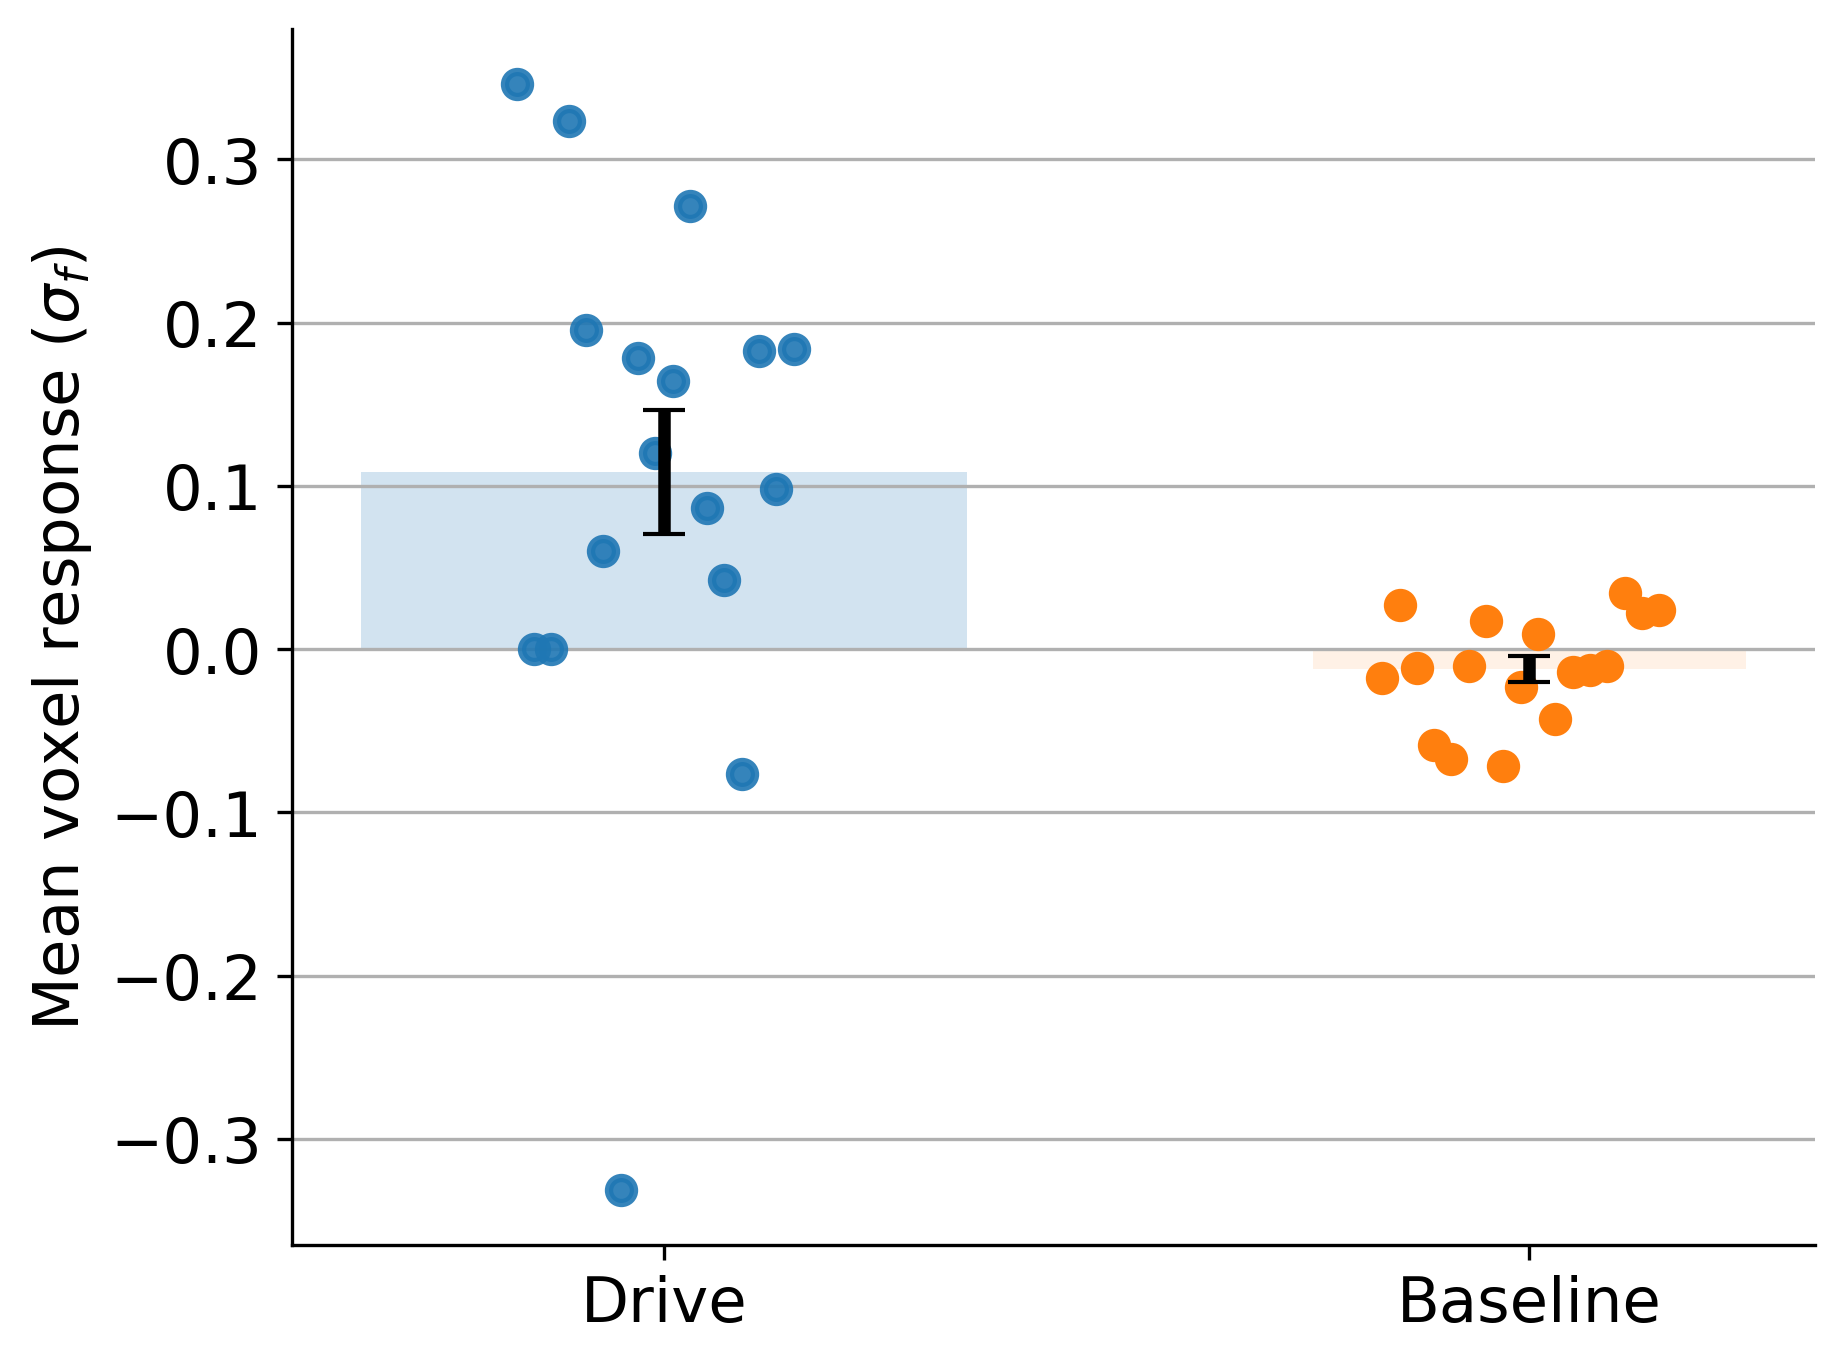

In [13]:
# Make average plot
# calculate means
use_clusters = False
m1 = m[use_clusters]
diag_means = np.diag(m1)
off_diag_means = np.nanmean(m1, axis=1) - (diag_means / len(diag_means))
neuro.sasc.viz.barplot_default([diag_means], [off_diag_means],
                               pilot_name, expls, annot_points=False)
joblib.dump({'diag_means': diag_means,
            'off_diag_means': off_diag_means, 'voxel_num': rows['voxel_num'].values},
            join(config.RESULTS_DIR_LOCAL, 'gct_processed', pilot_name.replace('_story_data.pkl', '_default_means.pkl')))

### Relationship between different voxels

In [24]:
# note: some voxels didn't have good clusters so they will be missing from these plots...
use_clusters = False
m1 = m[use_clusters]

neuro.sasc.viz.outline_diagonal(m1.shape, color='black', lw=1, block_size=1)

s = 'small'
# expls_order = analyze_helper.sort_expls_semantically(expls, device='cuda')
expls_order = np.argsort(expls)
if pilot_name == 'pilot_story_data.pkl':
    expls_order = expls_order[[15, 7, 11, 14, 3,
                               12, 4, 1, 2, 0, 13, 6, 5, 16, 10, 9, 8]]
m_plot = m1[expls_order][:, expls_order]  # [:, expls_order]
neuro.sasc.viz.imshow_diverging(
    m_plot, clab="Mean response ($\sigma$)", clab_size='large')
plt.xlabel("Driving paragraph",  # \n(Ideally, diagonal should be brighter)",
           fontsize='large')

# plt.ylabel("Voxel", fontsize='x-small')
# labs = expls[expls_order]

plt.ylabel("Voxel number", fontsize='large')
labs = [f'{i + 1:02d}' for i in range(len(expls_order))]
for i in range(len(labs)):
    print(labs[i], expls[expls_order[i]])

plt.yticks(labels=labs, ticks=np.arange(
    len(expls)), fontsize=s)
plt.xticks(labels=labs, ticks=np.arange(
    len(expls)), rotation=90, fontsize=s)
plt.tight_layout()
neuro.viz.savefig(join('default',
                       pilot_name[:pilot_name.index('_')] + '_default_heatmap.pdf'), bbox_inches='tight')
plt.show()

# plot correlations across all resps
# resps_voxels = np.concatenate(
#     [resps_dict[story_data["story_name_new"][story_num]].T for story_num in [2, 3, 4]],
#     axis=1,
# )[rw["voxel_num"].values]
# corr = pd.DataFrame(resps_voxels.T, columns=expls).corr().round(2)
# sns.clustermap(corr)

<>:15: DeprecationWarning: invalid escape sequence '\s'
<>:15: DeprecationWarning: invalid escape sequence '\s'
/tmp/ipykernel_3768672/1431878391.py:15: DeprecationWarning: invalid escape sequence '\s'
  m_plot, clab="Mean response ($\sigma$)", clab_size='large')


01 surprise
02 laughter
03 moments
04 rejection
05 emotion
06 negativity
07 emotional expression
08 communication
09 death
10 birthdays
11 physical injury or trauma
12 hair and clothing
13 food preparation
14 time
15 measurements
16 locations
17 locations


### Story-level differences

In [ ]:
def get_story_df(mats1, melt=False):
    d = defaultdict(list)
    story_names = resp_np_files
    for i in range(len(mats1)):
        m = mats1[i]
        d['driving'].append(np.nanmean(np.diag(m)))
        d['baseline'].append(np.nanmean(m[~np.eye(m.shape[0], dtype=bool)]))
        d['story'].append(story_names[i].replace('.npy', ''))
    d = pd.DataFrame.from_dict(d)
    if melt:
        d = d.melt(id_vars='story', value_vars=[
            'driving', 'baseline'], var_name='condition', value_name='mean')
        d = d[d.condition == 'driving']
    return d


use_clusters = False
mats1 = mats[use_clusters]
story_scores_df = get_story_df(mats1)
joblib.dump(story_scores_df, join(config.RESULTS_DIR, 'processed',
            pilot_name.replace('_story_data.pkl', '_default_story_scores.pkl')))

neuro.sasc.viz.stories_barplot(story_scores_df)

# Statistical tests

### Test per subject

In [ ]:
m1.shape

In [ ]:
m1.shape
diags = np.diag(m1)
off_diags = m1[~np.eye(m1.shape[0], dtype=bool)]

n_permutations = 10000
n_pick = len(diags)
baseline_distr = []
rng = np.random.default_rng(42)
for i in range(n_permutations):
    sample = rng.choice(
        off_diags, n_pick, replace=False)
    baseline_distr.append(np.nanmean(sample))
baseline_distr = np.array(baseline_distr)
p = np.mean(baseline_distr > np.nanmean(diags))
print(pilot_name, p)
PS = {
    'UTS01': 0.0202,
    'UTS02': 0,
    'UTS03': 0.0057,
}
false_discovery_control(list(PS.values()))

### Test per voxel

In [ ]:
# n_stories, n_voxels, driving_paragraph
diag_means2 = []
mats_list = mats[use_clusters]
ps_per_voxel = []
for vox_num in range(mats_list.shape[1]):
    driving_paragraph_means = mats_list[:, vox_num, vox_num]
    non_driving_paragraph_means = np.delete(
        mats_list[:, vox_num, :], vox_num, axis=-1).flatten()

    # permutation test per voxel
    n_permutations = 1000
    n_pick = len(driving_paragraph_means)
    baseline_distr = []
    rng = np.random.default_rng(42)
    for i in range(n_permutations):
        sample = rng.choice(
            non_driving_paragraph_means, n_pick, replace=False)
        baseline_distr.append(np.nanmean(sample))
    baseline_distr = np.array(baseline_distr)
    p = np.mean(baseline_distr > np.nanmean(driving_paragraph_means))
    ps_per_voxel.append(p)

    # note: actual min should be 1 / num_possible_permutations
print(ps_per_voxel)
PS_PER_VOXEL_OUTPUT = {
    'UTS01': [0.497, 0.123, 0.304, 0.113, 0.157, 0.478, 0.836, 0.072, 0.273, 0.325, 0.426, 0.251, 0.626, 0.04, 0.109, 0.664, 0.704],
    'UTS02': [0.771, 0.835, 0.07, 0.113, 0.0, 0.167, 0.037, 0.112, 0.018, 0.351, 0.005, 0.0, 0.0, 0.0, 0.019, 0.775, 0.006],
    'UTS03': [0.003, 0.485, 0.491, 0.074, 0.103, 0.318, 0.961, 0.103, 0.218, 0.182, 0.057, 0.282, 0.392, 0.699, 0.287, 0.37, 0.201],
}

# Extra analysis for UTS02

### Clusters vs non-clusters

In [ ]:
sns.color_palette("Blues", 2)[0]

In [ ]:
assert pilot_name == 'pilot_story_data.pkl'
df1 = get_story_df(mats[False], melt=True)
df1['Setting'] = 'Single voxel'
df2 = get_story_df(mats[True], melt=True)
df2['Setting'] = 'Voxel cluster'
df = pd.concat([df1, df2])
df['story'] = df['story'].str.replace('GenStory', '')

sns.barplot(data=df, x='story', y='mean',
            hue='Setting',
            width=0.8,
            palette=[sns.color_palette("Blues", 3)[0], 'lightgray'],
            )
plt.xlabel("Story")
plt.ylabel('Mean driving voxel response ($\sigma$)')
plt.savefig(join(config.RESULTS_DIR, 'figs/misc',
            'cluster_vs_single_default_story_breakdown.pdf'))

### Good prompt vs bad prompt

In [ ]:
assert pilot_name == 'pilot_story_data.pkl'
df = get_story_df(mats[False], melt=True)
good_prompt = ['GenStory2', 'GenStory3', 'GenStory4']
df['Prompt'] = df.apply(lambda x: x['story'] in good_prompt, axis=1)
df['Prompt'] = df['Prompt'].map(
    {True: 'Prompt version 1', False: 'Prompt version 0'})
df = df.sort_values(by='Prompt', ascending=False)
df['story'] = df['story'].str.replace('GenStory', '')


# shade bars by prompt version
offset = 0
xticklabels = []
for i, prompt in enumerate(df['Prompt'].unique()):
    d = df[df['Prompt'] == prompt]
    d = d.sort_values('story')
    plt.bar(np.arange(len(d)) + offset, d['mean'], label=prompt,
            color=sns.color_palette("Blues", 3)[0], hatch='' if i == 0 else '//')
    xticklabels += d['story'].tolist()
    offset += len(d)
plt.xticks(np.arange(len(xticklabels)), xticklabels)

plt.legend()
plt.xlabel("Story")
plt.ylabel('Mean driving voxel response ($\sigma$)')
plt.savefig(join(config.RESULTS_DIR, 'figs/misc',
            'prompt_default_story_breakdown.pdf'))

### Voxel-level differences

In [ ]:
# add stats
def save_voxel_scores(m, rows, pilot_name):
    rows["driving_score"] = np.diag(m[False])
    rm = pd.read_pickle(join(config.RESULTS_DIR, 'neuro.sasc', "fmri_results_merged.pkl")).sort_values(
        by=["stability_score"], ascending=False
    )
    for k in ["fmri_test_corr_llama", "top_score_normalized_llama"]:
        rows[k] = rows.apply(
            lambda row: rm[
                (rm.module_num == row.module_num) & (rm.subject == row.subject)
            ].iloc[0][k],
            axis=1,
        ).values
    cols = ["expl", "driving_score", "stability_score", "top_score_normalized", "top_score_normalized_llama",
            "fmri_test_corr", "fmri_test_corr_llama", "module_num"]
    voxel_scores = rows[cols]
    joblib.dump(voxel_scores, join(config.RESULTS_DIR, 'processed',
                pilot_name.replace('_story_data.pkl', '_default_voxel_scores.pkl')))


save_voxel_scores(m, rows, pilot_name)

In [ ]:
sns.pairplot(rows[cols + ["expl"]], kind="reg")  # , hue='expl')